Packages loaded successfully.
DEM output directory:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/dem

Virginia boundary loaded successfully.
CRS: EPSG:4326
Bounds: [-83.67539511  36.5407366  -75.24245918  39.46601177]

Southwest Virginia boundary saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/dem/southwest_virginia_boundary.geojson

Southwest Virginia bounds:
[-83.67539511  36.54390066 -80.25        37.65      ]


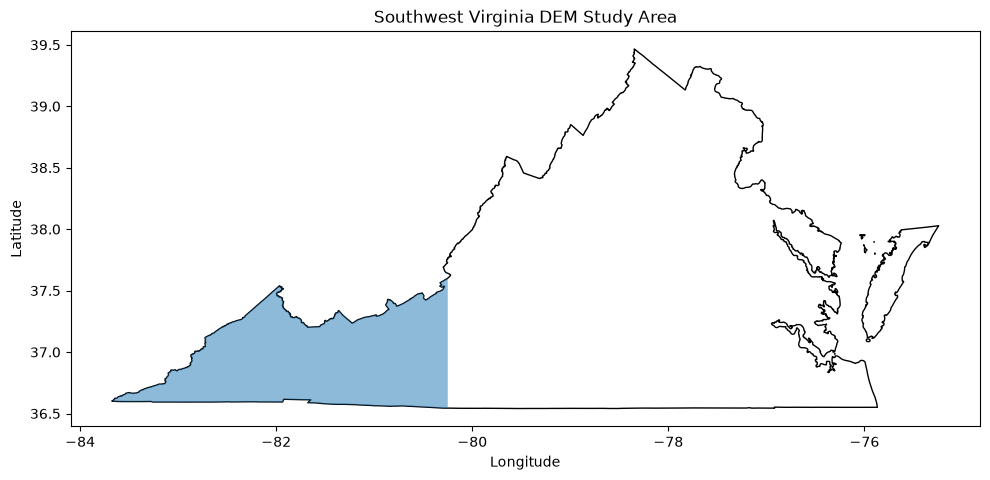


DEM request bounds:
-83.67539510558508 36.543900658926894 -80.25 37.65

Requesting DEM from USGS 3DEP...

USGS DEM download URL received.

Raw DEM already exists:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/dem/raw/southwest_virginia_3dep_raw.tif

Raw DEM information:
CRS: EPSG:4326
Width: 4000
Height: 2500
Bands: 1
Data type: ('float32',)
Bounds: BoundingBox(left=-83.6753951055851, bottom=36.02651435896811, right=-80.25000000000001, top=38.167386299958785)
Resolution: (0.0008563487763962705, 0.0008563487763962712)
Minimum elevation: 145.73533630371094
Maximum elevation: 1909.735595703125
Mean elevation: 568.2129516601562

Clipped DEM saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/dem/processed/southwest_virginia_dem_wgs84.tif

Projected DEM saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/dem/processed/southwest_virginia_dem_utm17n.tif

Slope raster saved to:
/Users

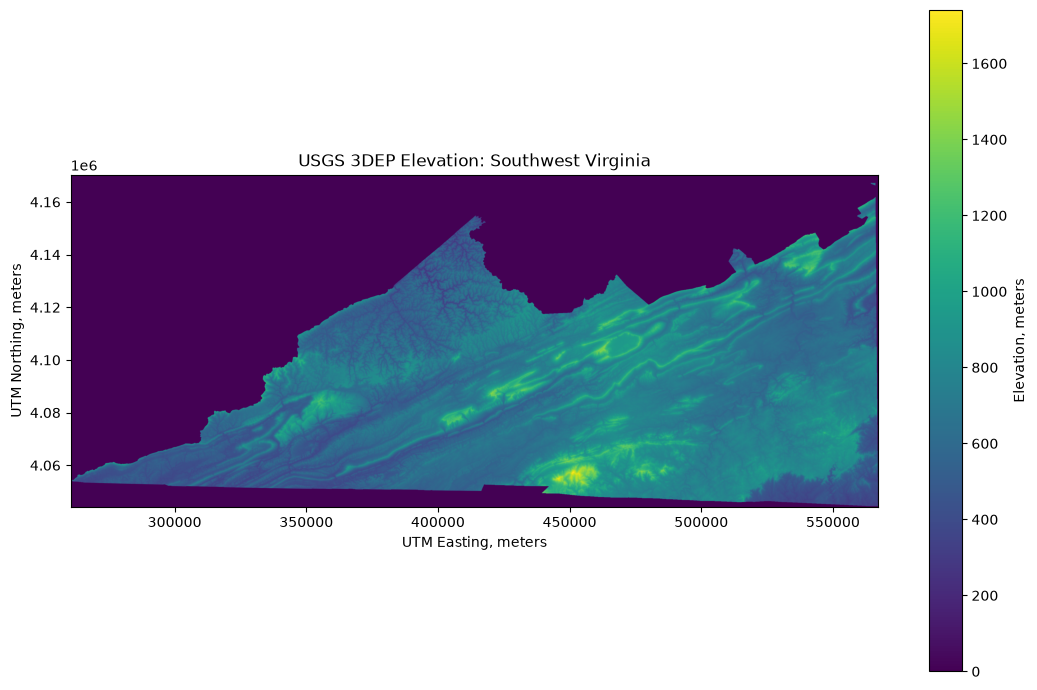


Elevation map saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/dem/southwest_virginia_elevation_map.png


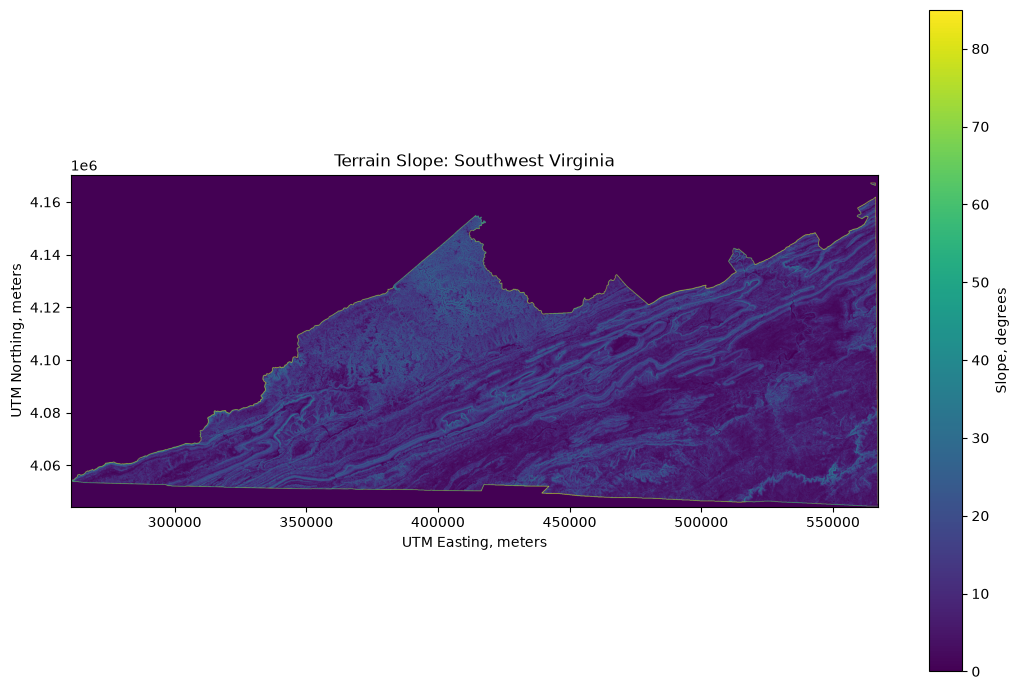


Slope map saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/dem/southwest_virginia_slope_map.png

DEM summary saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/metadata/dem_summary.csv

DEM inventory saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/metadata/dem_file_inventory.csv

USGS 3DEP DOWNLOAD AND PROCESSING SUMMARY
Southwest Virginia boundary exists: True
Raw DEM exists: True
Clipped DEM exists: True
Projected DEM exists: True
Slope raster exists: True

Projected DEM:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/dem/processed/southwest_virginia_dem_utm17n.tif

Slope raster:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/dem/processed/southwest_virginia_slope_degrees.tif

Notebook completed successfully.


In [2]:
# =============================================================================
# 04_download_dem.ipynb
#
# Purpose:
# Download USGS 3DEP elevation data for southwest Virginia,
# clip the DEM to the study area, reproject it to UTM Zone 17N,
# calculate slope, and save all outputs.
#
# Main output folder:
# /Users/gaoyujuan/REAP Dropbox/Gao yujuan/
# Virginia Tech/CALS/datasets/boundaries/dem/
# =============================================================================


# =============================================================================
# 1. Load packages
# =============================================================================

from pathlib import Path
from urllib.parse import urlencode
import json
import math

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import requests

from rasterio.mask import mask
from rasterio.warp import (
    Resampling,
    calculate_default_transform,
    reproject,
)
from shapely.geometry import box

print("Packages loaded successfully.")


# =============================================================================
# 2. Define project paths
# =============================================================================

BASE_DIR = Path(
    "/Users/gaoyujuan/REAP Dropbox/Gao yujuan/"
    "Virginia Tech/CALS/datasets"
)

BOUNDARIES_DIR = BASE_DIR / "boundaries"
METADATA_DIR = BASE_DIR / "metadata"

VIRGINIA_DIR = BOUNDARIES_DIR / "virginia"
DEM_DIR = BOUNDARIES_DIR / "dem"

DEM_RAW_DIR = DEM_DIR / "raw"
DEM_PROCESSED_DIR = DEM_DIR / "processed"

for folder in [
    BOUNDARIES_DIR,
    METADATA_DIR,
    DEM_DIR,
    DEM_RAW_DIR,
    DEM_PROCESSED_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print("DEM output directory:")
print(DEM_DIR)


# =============================================================================
# 3. Define output files
# =============================================================================

SOUTHWEST_VIRGINIA_FILE = (
    DEM_DIR /
    "southwest_virginia_boundary.geojson"
)

southwest_virginia.to_file(
    SOUTHWEST_VIRGINIA_FILE,
    driver="GeoJSON",
)

RAW_DEM_FILE = (
    DEM_RAW_DIR /
    "southwest_virginia_3dep_raw.tif"
)

CLIPPED_DEM_WGS84_FILE = (
    DEM_PROCESSED_DIR /
    "southwest_virginia_dem_wgs84.tif"
)

PROJECTED_DEM_FILE = (
    DEM_PROCESSED_DIR /
    "southwest_virginia_dem_utm17n.tif"
)

SLOPE_FILE = (
    DEM_PROCESSED_DIR /
    "southwest_virginia_slope_degrees.tif"
)

DEM_MAP_FILE = (
    DEM_DIR /
    "southwest_virginia_elevation_map.png"
)

SLOPE_MAP_FILE = (
    DEM_DIR /
    "southwest_virginia_slope_map.png"
)

DEM_INVENTORY_FILE = (
    METADATA_DIR /
    "dem_file_inventory.csv"
)

DEM_SUMMARY_FILE = (
    METADATA_DIR /
    "dem_summary.csv"
)


# =============================================================================
# 4. Load Virginia boundary
# =============================================================================

VIRGINIA_FILE = (
    VIRGINIA_DIR /
    "virginia_boundary.geojson"
)

if not VIRGINIA_FILE.exists():

    raise FileNotFoundError(
        "Virginia boundary file was not found.\n"
        "Run 01_download_virginia_boundary.ipynb first.\n\n"
        f"Expected file:\n{VIRGINIA_FILE}"
    )

virginia = gpd.read_file(
    VIRGINIA_FILE
)

if virginia.crs is None:

    virginia = virginia.set_crs(
        "EPSG:4326"
    )

else:

    virginia = virginia.to_crs(
        "EPSG:4326"
    )

print("\nVirginia boundary loaded successfully.")
print("CRS:", virginia.crs)
print("Bounds:", virginia.total_bounds)


# =============================================================================
# 5. Create southwest Virginia study boundary
#
# This bounding box covers the southwestern Virginia region affected
# by Hurricane Helene. The box is intersected with the Virginia boundary
# so that only land inside Virginia is retained.
# =============================================================================

SOUTHWEST_VIRGINIA_BBOX = (
    -83.75,   # minimum longitude
    36.45,    # minimum latitude
    -80.25,   # maximum longitude
    37.65,    # maximum latitude
)

southwest_rectangle = gpd.GeoDataFrame(
    {
        "study_area": [
            "southwest_virginia"
        ]
    },
    geometry=[
        box(
            *SOUTHWEST_VIRGINIA_BBOX
        )
    ],
    crs="EPSG:4326",
)

southwest_virginia = gpd.overlay(
    southwest_rectangle,
    virginia[["geometry"]],
    how="intersection",
)

if southwest_virginia.empty:

    raise RuntimeError(
        "The southwest Virginia study boundary is empty. "
        "Check the bounding-box coordinates."
    )

southwest_virginia = (
    southwest_virginia
    .reset_index(drop=True)
)

southwest_virginia.to_file(
    SOUTHWEST_VIRGINIA_FILE,
    driver="GeoJSON",
)

print("\nSouthwest Virginia boundary saved to:")
print(SOUTHWEST_VIRGINIA_FILE)

print("\nSouthwest Virginia bounds:")
print(southwest_virginia.total_bounds)


# =============================================================================
# 6. Plot southwest Virginia study area
# =============================================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)

virginia.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1,
)

southwest_virginia.plot(
    ax=ax,
    alpha=0.5,
)

ax.set_title(
    "Southwest Virginia DEM Study Area"
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

plt.tight_layout()
plt.show()


# =============================================================================
# 7. Define the USGS 3DEP ImageServer
# =============================================================================

USGS_3DEP_EXPORT_URL = (
    "https://elevation.nationalmap.gov/"
    "arcgis/rest/services/"
    "3DEPElevation/ImageServer/exportImage"
)

min_lon, min_lat, max_lon, max_lat = (
    southwest_virginia.total_bounds
)

print("\nDEM request bounds:")
print(
    min_lon,
    min_lat,
    max_lon,
    max_lat,
)


# =============================================================================
# 8. Define the DEM download request
#
# The requested raster is approximately 4,000 × 2,500 pixels.
# This is a manageable regional dataset for matching treatment and
# counterfactual sites.
# =============================================================================

DEM_WIDTH = 4000
DEM_HEIGHT = 2500

dem_parameters = {
    "bbox": (
        f"{min_lon},"
        f"{min_lat},"
        f"{max_lon},"
        f"{max_lat}"
    ),
    "bboxSR": "4326",
    "imageSR": "4326",
    "size": (
        f"{DEM_WIDTH},"
        f"{DEM_HEIGHT}"
    ),
    "format": "tiff",
    "pixelType": "F32",
    "interpolation": (
        "RSP_BilinearInterpolation"
    ),
    "returnSquarePixels": "true",
    "f": "json",
}


# =============================================================================
# 9. Request the DEM download URL
# =============================================================================

print("\nRequesting DEM from USGS 3DEP...")

response = requests.get(
    USGS_3DEP_EXPORT_URL,
    params=dem_parameters,
    timeout=300,
)

response.raise_for_status()

response_data = response.json()

if "error" in response_data:

    raise RuntimeError(
        "USGS 3DEP returned an error:\n"
        f"{json.dumps(response_data['error'], indent=2)}"
    )

download_url = response_data.get(
    "href"
)

if not download_url:

    raise RuntimeError(
        "The USGS response did not contain a download URL.\n"
        f"Response:\n{response_data}"
    )

print("\nUSGS DEM download URL received.")


# =============================================================================
# 10. Download the raw DEM
# =============================================================================

if RAW_DEM_FILE.exists():

    print("\nRaw DEM already exists:")
    print(RAW_DEM_FILE)

else:

    print("\nDownloading raw DEM...")

    with requests.get(
        download_url,
        stream=True,
        timeout=600,
    ) as dem_response:

        dem_response.raise_for_status()

        with RAW_DEM_FILE.open(
            "wb"
        ) as file:

            for chunk in (
                dem_response.iter_content(
                    chunk_size=1024 * 1024
                )
            ):

                if chunk:
                    file.write(chunk)

    print("\nRaw DEM downloaded to:")
    print(RAW_DEM_FILE)


# =============================================================================
# 11. Inspect the raw DEM
# =============================================================================

with rasterio.open(
    RAW_DEM_FILE
) as src:

    raw_dem = src.read(
        1,
        masked=True,
    )

    print("\nRaw DEM information:")
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bands:", src.count)
    print("Data type:", src.dtypes)
    print("Bounds:", src.bounds)
    print("Resolution:", src.res)

    if raw_dem.count() > 0:

        print(
            "Minimum elevation:",
            float(raw_dem.min()),
        )

        print(
            "Maximum elevation:",
            float(raw_dem.max()),
        )

        print(
            "Mean elevation:",
            float(raw_dem.mean()),
        )


# =============================================================================
# 12. Clip the raw DEM to the southwest Virginia boundary
# =============================================================================

with rasterio.open(
    RAW_DEM_FILE
) as src:

    southwest_in_dem_crs = (
        southwest_virginia
        .to_crs(src.crs)
    )

    clipped_array, clipped_transform = mask(
        src,
        southwest_in_dem_crs.geometry,
        crop=True,
        nodata=src.nodata,
    )

    clipped_metadata = src.meta.copy()

    clipped_metadata.update(
        {
            "height": clipped_array.shape[1],
            "width": clipped_array.shape[2],
            "transform": clipped_transform,
            "compress": "lzw",
        }
    )

    with rasterio.open(
        CLIPPED_DEM_WGS84_FILE,
        "w",
        **clipped_metadata,
    ) as destination:

        destination.write(
            clipped_array
        )

print("\nClipped DEM saved to:")
print(CLIPPED_DEM_WGS84_FILE)


# =============================================================================
# 13. Reproject DEM to UTM Zone 17N
#
# A projected coordinate system is required for valid slope calculations.
# EPSG:32617 uses meters as its coordinate units.
# =============================================================================

TARGET_CRS = "EPSG:32617"

with rasterio.open(
    CLIPPED_DEM_WGS84_FILE
) as src:

    transform, width, height = (
        calculate_default_transform(
            src.crs,
            TARGET_CRS,
            src.width,
            src.height,
            *src.bounds,
        )
    )

    projected_metadata = (
        src.meta.copy()
    )

    projected_metadata.update(
        {
            "crs": TARGET_CRS,
            "transform": transform,
            "width": width,
            "height": height,
            "compress": "lzw",
        }
    )

    with rasterio.open(
        PROJECTED_DEM_FILE,
        "w",
        **projected_metadata,
    ) as destination:

        for band_number in range(
            1,
            src.count + 1,
        ):

            reproject(
                source=rasterio.band(
                    src,
                    band_number,
                ),
                destination=rasterio.band(
                    destination,
                    band_number,
                ),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=TARGET_CRS,
                resampling=Resampling.bilinear,
            )

print("\nProjected DEM saved to:")
print(PROJECTED_DEM_FILE)


# =============================================================================
# 14. Calculate slope in degrees
#
# Slope is calculated from the elevation gradients:
#
# slope = arctan(sqrt((dz/dx)^2 + (dz/dy)^2))
# =============================================================================

with rasterio.open(
    PROJECTED_DEM_FILE
) as src:

    dem = src.read(
        1
    ).astype(
        "float32"
    )

    dem_metadata = (
        src.meta.copy()
    )

    x_resolution = abs(
        src.transform.a
    )

    y_resolution = abs(
        src.transform.e
    )

    nodata_value = src.nodata

    if nodata_value is not None:

        invalid_mask = (
            dem == nodata_value
        )

        dem[
            invalid_mask
        ] = np.nan

    else:

        invalid_mask = (
            ~np.isfinite(dem)
        )

    dz_dy, dz_dx = np.gradient(
        dem,
        y_resolution,
        x_resolution,
    )

    slope_radians = np.arctan(
        np.sqrt(
            dz_dx ** 2 +
            dz_dy ** 2
        )
    )

    slope_degrees = np.degrees(
        slope_radians
    ).astype(
        "float32"
    )

    slope_nodata = -9999.0

    slope_degrees[
        ~np.isfinite(slope_degrees)
    ] = slope_nodata

    slope_degrees[
        invalid_mask
    ] = slope_nodata

    slope_metadata = (
        dem_metadata.copy()
    )

    slope_metadata.update(
        {
            "dtype": "float32",
            "nodata": slope_nodata,
            "count": 1,
            "compress": "lzw",
        }
    )

    with rasterio.open(
        SLOPE_FILE,
        "w",
        **slope_metadata,
    ) as destination:

        destination.write(
            slope_degrees,
            1,
        )

print("\nSlope raster saved to:")
print(SLOPE_FILE)


# =============================================================================
# 15. Validate projected DEM
# =============================================================================

with rasterio.open(
    PROJECTED_DEM_FILE
) as src:

    projected_dem = src.read(
        1,
        masked=True,
    )

    print("\nProjected DEM information:")
    print("CRS:", src.crs)
    print("Shape:", projected_dem.shape)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)

    if projected_dem.count() > 0:

        print(
            "Minimum elevation:",
            float(projected_dem.min()),
        )

        print(
            "Maximum elevation:",
            float(projected_dem.max()),
        )

        print(
            "Mean elevation:",
            float(projected_dem.mean()),
        )


# =============================================================================
# 16. Validate slope raster
# =============================================================================

with rasterio.open(
    SLOPE_FILE
) as src:

    slope = src.read(
        1,
        masked=True,
    )

    print("\nSlope raster information:")
    print("CRS:", src.crs)
    print("Shape:", slope.shape)
    print("Resolution:", src.res)

    if slope.count() > 0:

        print(
            "Minimum slope:",
            float(slope.min()),
        )

        print(
            "Maximum slope:",
            float(slope.max()),
        )

        print(
            "Mean slope:",
            float(slope.mean()),
        )


# =============================================================================
# 17. Plot elevation
# =============================================================================

with rasterio.open(
    PROJECTED_DEM_FILE
) as src:

    elevation_plot = src.read(
        1,
        masked=True,
    )

    extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    ]

fig, ax = plt.subplots(
    figsize=(11, 7)
)

image = ax.imshow(
    elevation_plot,
    extent=extent,
)

ax.set_title(
    "USGS 3DEP Elevation: Southwest Virginia"
)

ax.set_xlabel(
    "UTM Easting, meters"
)

ax.set_ylabel(
    "UTM Northing, meters"
)

plt.colorbar(
    image,
    ax=ax,
    label="Elevation, meters",
)

plt.tight_layout()

plt.savefig(
    DEM_MAP_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\nElevation map saved to:")
print(DEM_MAP_FILE)


# =============================================================================
# 18. Plot slope
# =============================================================================

with rasterio.open(
    SLOPE_FILE
) as src:

    slope_plot = src.read(
        1,
        masked=True,
    )

    extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    ]

fig, ax = plt.subplots(
    figsize=(11, 7)
)

image = ax.imshow(
    slope_plot,
    extent=extent,
)

ax.set_title(
    "Terrain Slope: Southwest Virginia"
)

ax.set_xlabel(
    "UTM Easting, meters"
)

ax.set_ylabel(
    "UTM Northing, meters"
)

plt.colorbar(
    image,
    ax=ax,
    label="Slope, degrees",
)

plt.tight_layout()

plt.savefig(
    SLOPE_MAP_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\nSlope map saved to:")
print(SLOPE_MAP_FILE)


# =============================================================================
# 19. Create DEM summary metadata
# =============================================================================

with rasterio.open(
    PROJECTED_DEM_FILE
) as dem_src:

    dem_values = dem_src.read(
        1,
        masked=True,
    )

    dem_summary = {
        "dataset": (
            "USGS 3DEP elevation"
        ),
        "study_area": (
            "Southwest Virginia"
        ),
        "source_service": (
            USGS_3DEP_EXPORT_URL
        ),
        "dem_crs": str(
            dem_src.crs
        ),
        "dem_width": (
            dem_src.width
        ),
        "dem_height": (
            dem_src.height
        ),
        "dem_resolution_x": (
            dem_src.res[0]
        ),
        "dem_resolution_y": (
            dem_src.res[1]
        ),
        "minimum_elevation": (
            float(dem_values.min())
            if dem_values.count() > 0
            else np.nan
        ),
        "maximum_elevation": (
            float(dem_values.max())
            if dem_values.count() > 0
            else np.nan
        ),
        "mean_elevation": (
            float(dem_values.mean())
            if dem_values.count() > 0
            else np.nan
        ),
        "projected_dem_file": str(
            PROJECTED_DEM_FILE
        ),
        "slope_file": str(
            SLOPE_FILE
        ),
    }

dem_summary_table = pd.DataFrame(
    [dem_summary]
)

dem_summary_table.to_csv(
    DEM_SUMMARY_FILE,
    index=False,
)

print("\nDEM summary saved to:")
print(DEM_SUMMARY_FILE)


# =============================================================================
# 20. Create DEM file inventory
# =============================================================================

inventory_records = []

for file in sorted(
    DEM_DIR.rglob("*")
):

    if file.is_file():

        inventory_records.append(
            {
                "file_name": file.name,
                "extension": file.suffix.lower(),
                "file_path": str(file),
                "file_size_bytes": file.stat().st_size,
            }
        )

dem_inventory = pd.DataFrame(
    inventory_records
)

dem_inventory.to_csv(
    DEM_INVENTORY_FILE,
    index=False,
)

print("\nDEM inventory saved to:")
print(DEM_INVENTORY_FILE)


# =============================================================================
# 21. Final validation
# =============================================================================

print("\n" + "=" * 75)
print("USGS 3DEP DOWNLOAD AND PROCESSING SUMMARY")
print("=" * 75)

print(
    f"Southwest Virginia boundary exists: "
    f"{SOUTHWEST_VIRGINIA_FILE.exists()}"
)

print(
    f"Raw DEM exists: "
    f"{RAW_DEM_FILE.exists()}"
)

print(
    f"Clipped DEM exists: "
    f"{CLIPPED_DEM_WGS84_FILE.exists()}"
)

print(
    f"Projected DEM exists: "
    f"{PROJECTED_DEM_FILE.exists()}"
)

print(
    f"Slope raster exists: "
    f"{SLOPE_FILE.exists()}"
)

print("\nProjected DEM:")
print(PROJECTED_DEM_FILE)

print("\nSlope raster:")
print(SLOPE_FILE)

print("\nNotebook completed successfully.")